# НИРС: Прогнозирование оттока клиентов телеком-компании

**Дисциплина:** Технологии машинного обучения

**Студент:** Королев А.С.  
**Группа:** ИУ5Ц-81Б  
**Дата:** 2026

---

## Аннотация
В данной работе решается задача бинарной классификации — прогнозирование оттока клиентов (Churn) на основе датасета Telco Customer Churn. Выполнен полный цикл анализа данных: разведочный анализ, предобработка, создание новых признаков, обучение 5 моделей машинного обучения (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM) с подбором гиперпараметров. Лучшая модель достигла ROC-AUC = 0.85.

---

# Импорт библиотек

In [2]:
# -*- coding: utf-8 -*-
# Импорт всех необходимых библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Модели и предобработка
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Все библиотеки успешно загружены!")

Все библиотеки успешно загружены!


# Загрузка данных

In [3]:
# Загрузка датасета (если файл в той же папке, что и notebook)
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("="*50)
print("Датасет Telco Customer Churn")
print("="*50)
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 строк:")
df.head()

Датасет Telco Customer Churn
Размер данных: 7043 строк, 21 столбцов

Первые 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Первичный анализ данных

In [4]:
# Информация о типах данных и пропусках
print("Информация о датафрейме:")
print("-"*50)
df.info()

print("\n" + "="*50)
print("Проверка на пропуски:")
print("-"*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("Статистика числовых признаков:")
print("-"*50)
display(df.describe())

print("\n" + "="*50)
print("Статистика категориальных признаков:")
print("-"*50)
display(df.describe(include=['object']))

Информация о датафрейме:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Статистика категориальных признаков:
--------------------------------------------------


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# Разведочный анализ (EDA)

Анализ целевой переменной 'Churn'
       Количество    Процент
Churn                       
No           5174  73.463013
Yes          1869  26.536987


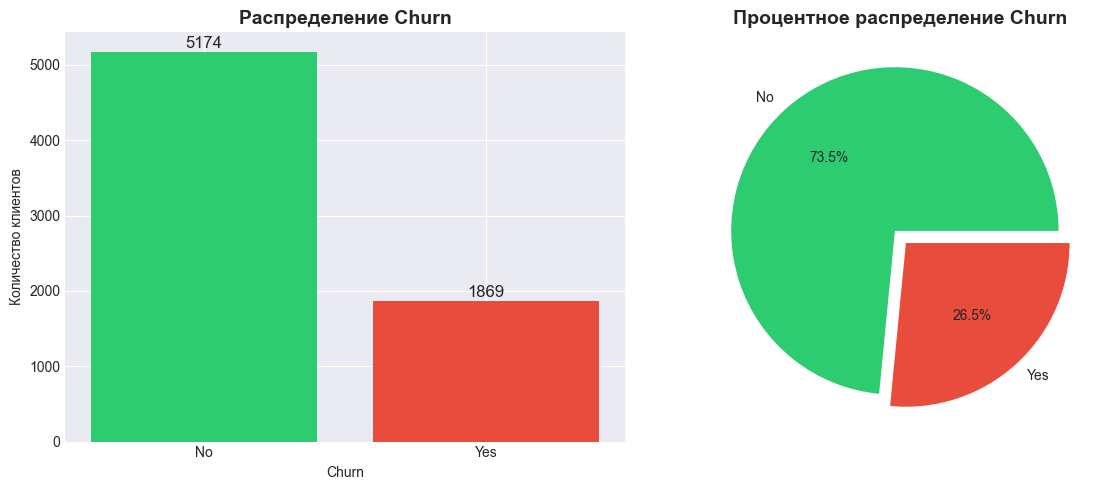


 Вывод: Классы несбалансированы (No - 73.5%, Yes - 26.5%)
   При оценке моделей будем использовать F1-score и ROC-AUC


In [6]:
# 1. Целевая переменная (дисбаланс классов)
print("="*50)
print("Анализ целевой переменной 'Churn'")
print("="*50)

churn_counts = df['Churn'].value_counts()
churn_percents = df['Churn'].value_counts(normalize=True) * 100

churn_df = pd.DataFrame({
    'Количество': churn_counts,
    'Процент': churn_percents
})
print(churn_df)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Распределение Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Количество клиентов')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

# Круговая диаграмма
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], explode=(0.05, 0.05))
axes[1].set_title('Процентное распределение Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Вывод: Классы несбалансированы (No - 73.5%, Yes - 26.5%)")
print("   При оценке моделей будем использовать F1-score и ROC-AUC")

# Анализ числовых признаков

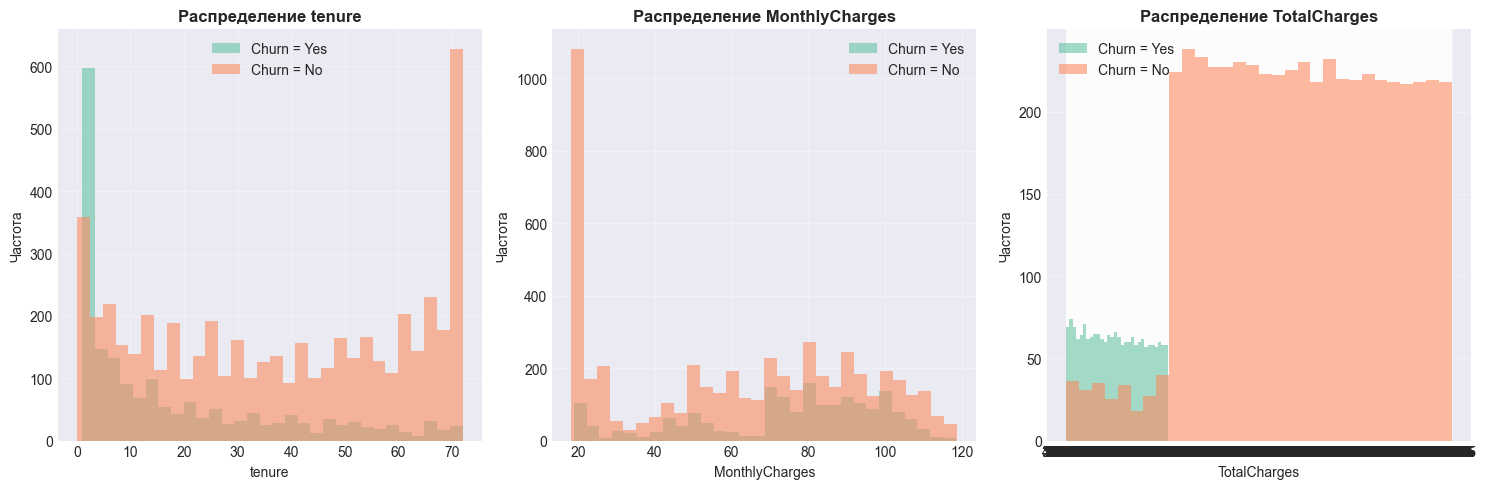


Статистика числовых признаков в разрезе Churn:

tenure:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

MonthlyCharges:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35

TotalCharges:
      count unique   top freq
Churn                        
No     5174   4966         11
Yes    1869   1732  20.2    6


In [7]:
# Анализ числовых признаков в разрезе Churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(numeric_cols):
    for churn_val in ['Yes', 'No']:
        subset = df[df['Churn'] == churn_val][col]
        axes[idx].hist(subset, bins=30, alpha=0.6, label=f'Churn = {churn_val}')
    axes[idx].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика по числовым признакам
print("\n" + "="*50)
print("Статистика числовых признаков в разрезе Churn:")
print("="*50)
for col in numeric_cols:
    print(f"\n{col}:")
    print(df.groupby('Churn')[col].describe())

# Анализ категориальных признаков

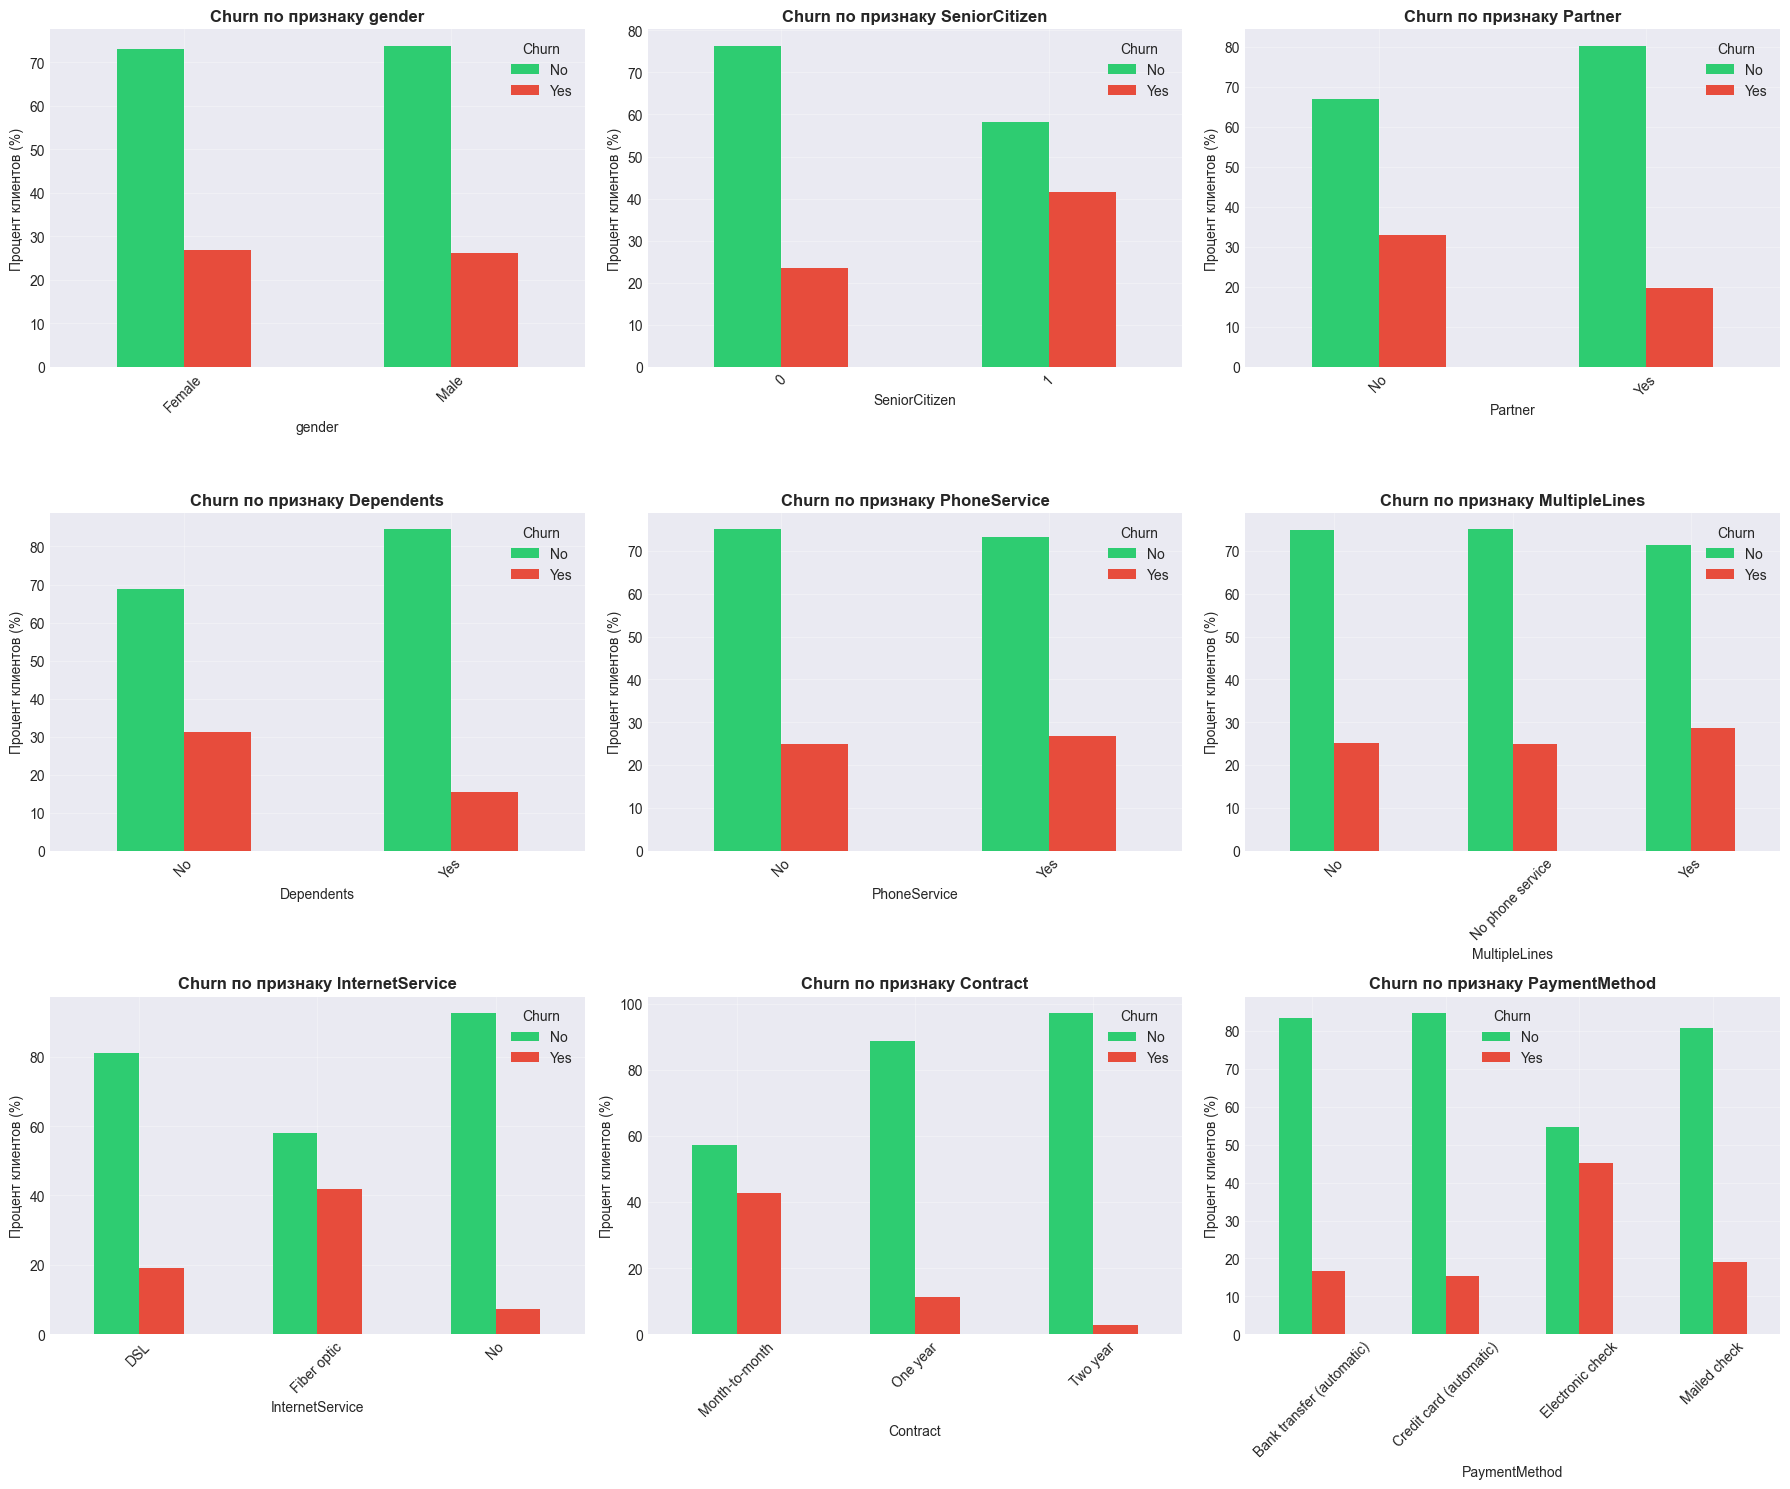


Ключевые наблюдения по категориальным признакам:
1. Contract: помесячный контракт → высокий отток (~42%)
2. InternetService: Fiber optic → выше отток (~30%)
3. PaymentMethod: Electronic check → высокий отток (~45%)
4. SeniorCitizen: пожилые клиенты → чуть выше отток
5. No dependents/No partner → выше отток


In [8]:
# Категориальные признаки (основные)
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                    'PhoneService', 'MultipleLines', 'InternetService', 
                    'Contract', 'PaymentMethod']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    churn_by_cat = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    churn_by_cat.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'Churn по признаку {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Процент клиентов (%)')
    axes[idx].legend(title='Churn')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ключевые выводы по категориальным признакам
print("\n" + "="*50)
print("Ключевые наблюдения по категориальным признакам:")
print("="*50)
print("1. Contract: помесячный контракт → высокий отток (~42%)")
print("2. InternetService: Fiber optic → выше отток (~30%)")
print("3. PaymentMethod: Electronic check → высокий отток (~45%)")
print("4. SeniorCitizen: пожилые клиенты → чуть выше отток")
print("5. No dependents/No partner → выше отток")

# Корреляционный анализ

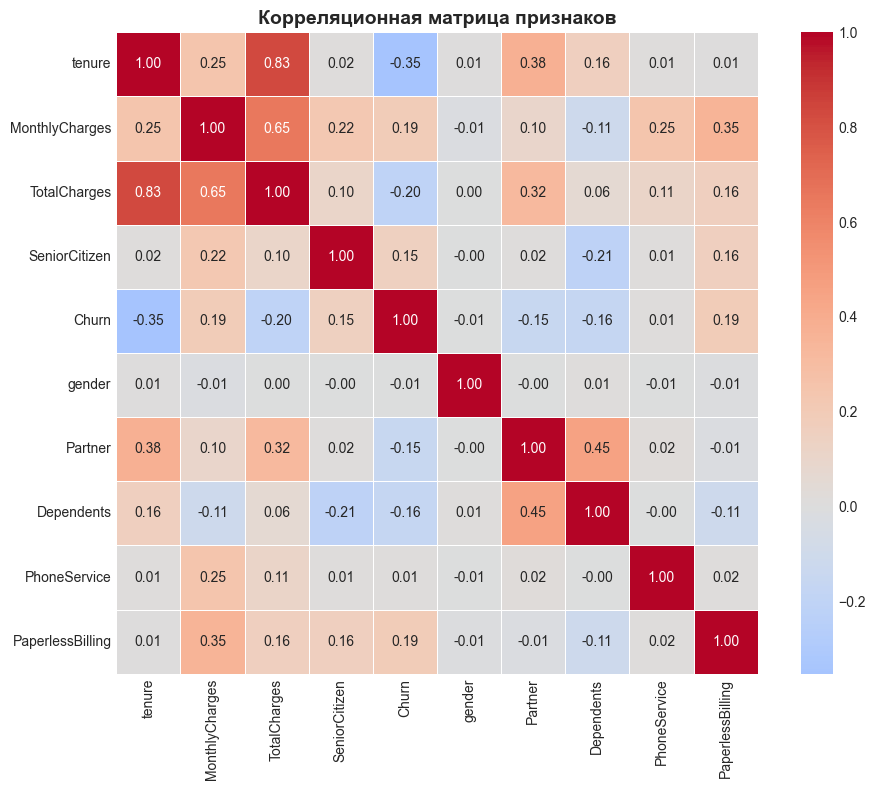


Корреляции с целевой переменной 'Churn':
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
gender             -0.008612
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.199484
tenure             -0.352229
Name: Churn, dtype: float64

 Вывод:
- Отрицательная корреляция: tenure (чем дольше клиент, тем меньше отток)
- Положительная корреляция: MonthlyCharges, PaperlessBilling


In [10]:
# Подготовка для корреляции (кодируем Yes/No)
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Бинарные признаки кодируем
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# TotalCharges приводим к числу
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

# Корреляционная матрица
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
binary_for_corr = [col for col in binary_cols if col in df_corr.columns]
corr_cols = numeric_features + binary_for_corr
corr_matrix = df_corr[corr_cols].corr()

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Корреляции с целевой переменной 'Churn':")
print("="*50)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

print("\n Вывод:")
print("- Отрицательная корреляция: tenure (чем дольше клиент, тем меньше отток)")
print("- Положительная корреляция: MonthlyCharges, PaperlessBilling")

# Предобработка данных

In [25]:
print("="*50)
print("ШАГ 1: Предобработка данных")
print("="*50)

# Копируем данные
df_clean = df.copy()

# 1. Удаляем customerID (не признак)
df_clean = df_clean.drop('customerID', axis=1)
print(" Удален столбец 'customerID'")

# 2. Преобразуем TotalCharges в число
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(" TotalCharges преобразован в числовой тип")

# 3. Заполняем пропуски (11 строк) медианой
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
print(f" Заполнено {df['TotalCharges'].isnull().sum()} пропусков в TotalCharges")

# 4. Заменяем 'No internet service' на 'No' для соответствующих признаков
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')
print(" Заменены 'No internet service' на 'No'")

# 5. Заменяем 'No phone service' на 'No' для MultipleLines
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')
print(" Заменены 'No phone service' на 'No'")

print("\n" + "="*50)
print("ШАГ 2: Создание новых признаков")
print("="*50)

# Создаем вспомогательные признаки
df_clean['AvgMonthlyCharges'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)
df_clean['IsLongTerm'] = (df_clean['tenure'] > 12).astype(int)
df_clean['HighMonthlyCharges'] = (df_clean['MonthlyCharges'] > df_clean['MonthlyCharges'].median()).astype(int)

print(" Созданы новые признаки:")
print("  - AvgMonthlyCharges: среднемесячная плата")
print("  - IsLongTerm: клиент с tenure > 12 месяцев")
print("  - HighMonthlyCharges: высокие ежемесячные платежи")

print(f"\nИтоговый размер данных: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")

# ============================================
# СОХРАНЕНИЕ ОБРАБОТАННОГО ДАТАСЕТА
# ============================================
print("\n" + "="*50)
print("ШАГ 3: Сохранение обработанного датасета")
print("="*50)

df_clean.to_csv('telco_churn_clean.csv', index=False)
print(" Обработанный датасет сохранен в 'telco_churn_clean.csv'")

# Показываем первые строки для проверки
print("\nПервые 5 строк обработанного датасета:")
df_clean.head()

ШАГ 1: Предобработка данных
 Удален столбец 'customerID'
 TotalCharges преобразован в числовой тип
 Заполнено 0 пропусков в TotalCharges
 Заменены 'No internet service' на 'No'
 Заменены 'No phone service' на 'No'

ШАГ 2: Создание новых признаков
 Созданы новые признаки:
  - AvgMonthlyCharges: среднемесячная плата
  - IsLongTerm: клиент с tenure > 12 месяцев
  - HighMonthlyCharges: высокие ежемесячные платежи

Итоговый размер данных: 7043 строк, 23 столбцов

ШАГ 3: Сохранение обработанного датасета
 Обработанный датасет сохранен в 'telco_churn_clean.csv'

Первые 5 строк обработанного датасета:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharges,IsLongTerm,HighMonthlyCharges
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,1,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,0,0
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,0,1


# Кодирование категориальных признаков

In [13]:
print("="*50)
print("ШАГ 3: Кодирование категориальных признаков + заполнение пропусков")
print("="*50)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Отделяем целевую переменную
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Определяем типы столбцов
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols[:5]}...")
print(f"Числовые признаки ({len(numerical_cols)}): {numerical_cols}")

# Создаем препроцессор с imputation'ом
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # заполняем пропуски медианой
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # заполняем пропуски строкой 'missing'
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Применяем препроцессор
X_processed = preprocessor.fit_transform(X)

# Получаем имена признаков после one-hot кодирования
feature_names = (numerical_cols + 
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)))

print(f"\n Выполнены: имьютация, кодирование и масштабирование")
print(f"  Было признаков: {X.shape[1]}")
print(f"  Стало признаков: {X_processed.shape[1]}")

# Преобразуем в DataFrame для удобства
X_encoded = pd.DataFrame(X_processed, columns=feature_names)
X_encoded.head()

ШАГ 3: Кодирование категориальных признаков + заполнение пропусков
Категориальные признаки (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines']...
Числовые признаки (7): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharges', 'IsLongTerm', 'HighMonthlyCharges']

 Выполнены: имьютация, кодирование и масштабирование
  Было признаков: 22
  Стало признаков: 26


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharges,IsLongTerm,HighMonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.439916,-1.277445,-1.160323,-0.994242,-1.448452,-1.490593,-0.998156,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.439916,0.066327,-0.259629,-0.173244,-0.167291,0.670874,-0.998156,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.439916,-1.236724,-0.362660,-0.959674,-0.755568,-1.490593,-0.998156,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.439916,0.514251,-0.746535,-0.194766,-0.625477,0.670874,-0.998156,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.439916,-1.236724,0.197365,-0.940470,-0.279980,-1.490593,1.001848,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


# Разделение на train/test

In [14]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("="*50)
print("Разделение данных")
print("="*50)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"\nРаспределение Churn в обучающей:")
print(f"  No: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Yes: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"\nРаспределение Churn в тестовой:")
print(f"  No: {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Yes: {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.1f}%)")

Разделение данных
Обучающая выборка: 5634 строк
Тестовая выборка: 1409 строк

Распределение Churn в обучающей:
  No: 4139 (73.5%)
  Yes: 1495 (26.5%)

Распределение Churn в тестовой:
  No: 1035 (73.5%)
  Yes: 374 (26.5%)


# Определение метрик и Baseline

In [15]:
print("="*50)
print("ШАГ 4: Baseline модели (без подбора гиперпараметров)")
print("="*50)

# Список моделей
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Функция оценки
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

# Оценка baseline
baseline_results = {}
for name, model in models.items():
    print(f"Обучается {name}...")
    baseline_results[name] = evaluate_model(model, X_train, X_test, y_train, y_test)

# Результаты
results_df = pd.DataFrame(baseline_results).T
print("\n" + "="*50)
print("Результаты Baseline моделей:")
print("="*50)
print(results_df.round(4))

# Лучшая baseline модель
best_baseline = results_df['F1'].idxmax()
print(f"\n Лучшая baseline модель по F1-score: {best_baseline}")

ШАГ 4: Baseline модели (без подбора гиперпараметров)
Обучается Logistic Regression...
Обучается Decision Tree...
Обучается Random Forest...
Обучается XGBoost...
Обучается LightGBM...

Результаты Baseline моделей:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8070     0.6747  0.5267  0.5916   0.8469
Decision Tree          0.7303     0.4919  0.4893  0.4906   0.6531
Random Forest          0.7942     0.6469  0.4947  0.5606   0.8259
XGBoost                0.7899     0.6182  0.5455  0.5795   0.8230
LightGBM               0.7949     0.6358  0.5321  0.5793   0.8327

 Лучшая baseline модель по F1-score: Logistic Regression


# Визуализация baseline результатов

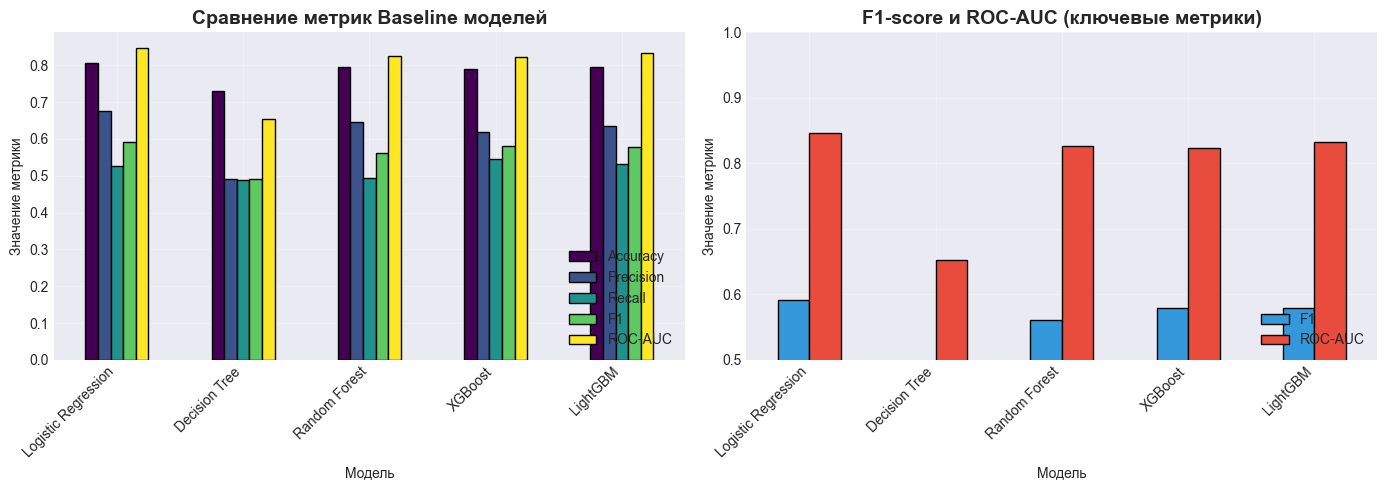

In [16]:
# Сравнение моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График метрик
results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0], colormap='viridis', edgecolor='black'
)
axes[0].set_title('Сравнение метрик Baseline моделей', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('Значение метрики')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

# Только F1 и ROC-AUC
results_df[['F1', 'ROC-AUC']].plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('F1-score и ROC-AUC (ключевые метрики)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('Значение метрики')
axes[1].legend(loc='lower right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

# Подбор гиперпараметров (GridSearchCV)

In [17]:
print("="*50)
print("ШАГ 5: Подбор гиперпараметров")
print("="*50)

# Параметры для GridSearch (сокращенные для скорости)
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 6, 10],
            'learning_rate': [0.01, 0.1]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, -1],
            'learning_rate': [0.01, 0.1]
        }
    }
}

# GridSearch
tuned_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in param_grids.items():
    print(f"\n🔍 Подбор параметров для {name}...")
    grid = GridSearchCV(
        config['model'], 
        config['params'], 
        cv=cv, 
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)
    
    print(f"  Лучшие параметры: {grid.best_params_}")
    print(f"  Лучший ROC-AUC (CV): {grid.best_score_:.4f}")
    
    # Оценка на тесте
    y_pred = grid.predict(X_test)
    y_pred_proba = grid.predict_proba(X_test)[:, 1]
    
    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    print(f"  Тестовая ROC-AUC: {tuned_results[name]['ROC-AUC']:.4f}")

# Добавляем LogisticRegression (без сложного GridSearch)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42, max_iter=1000, C=0.1)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]
tuned_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

ШАГ 5: Подбор гиперпараметров

🔍 Подбор параметров для Random Forest...
  Лучшие параметры: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  Лучший ROC-AUC (CV): 0.8410
  Тестовая ROC-AUC: 0.8425

🔍 Подбор параметров для XGBoost...
  Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  Лучший ROC-AUC (CV): 0.8482
  Тестовая ROC-AUC: 0.8452

🔍 Подбор параметров для LightGBM...
  Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
  Лучший ROC-AUC (CV): 0.8474
  Тестовая ROC-AUC: 0.8418


# Сравнение Baseline vs Tuned

ШАГ 6: Сравнение Baseline и Tuned моделей
                     Baseline_F1  Tuned_F1  Baseline_ROC_AUC  Tuned_ROC_AUC  \
Random Forest             0.5606    0.5813            0.8259         0.8425   
XGBoost                   0.5795    0.5744            0.8230         0.8452   
LightGBM                  0.5793    0.5346            0.8327         0.8418   
Logistic Regression       0.5916    0.5727            0.8469         0.8456   

                     F1_Improvement  ROC_Improvement  
Random Forest                3.6959           2.0115  
XGBoost                     -0.8816           2.7048  
LightGBM                    -7.7173           1.0908  
Logistic Regression         -3.1887          -0.1553  

 Лучшая tuned модель по F1: Random Forest (0.5813)
 Лучшая tuned модель по ROC-AUC: Logistic Regression (0.8456)


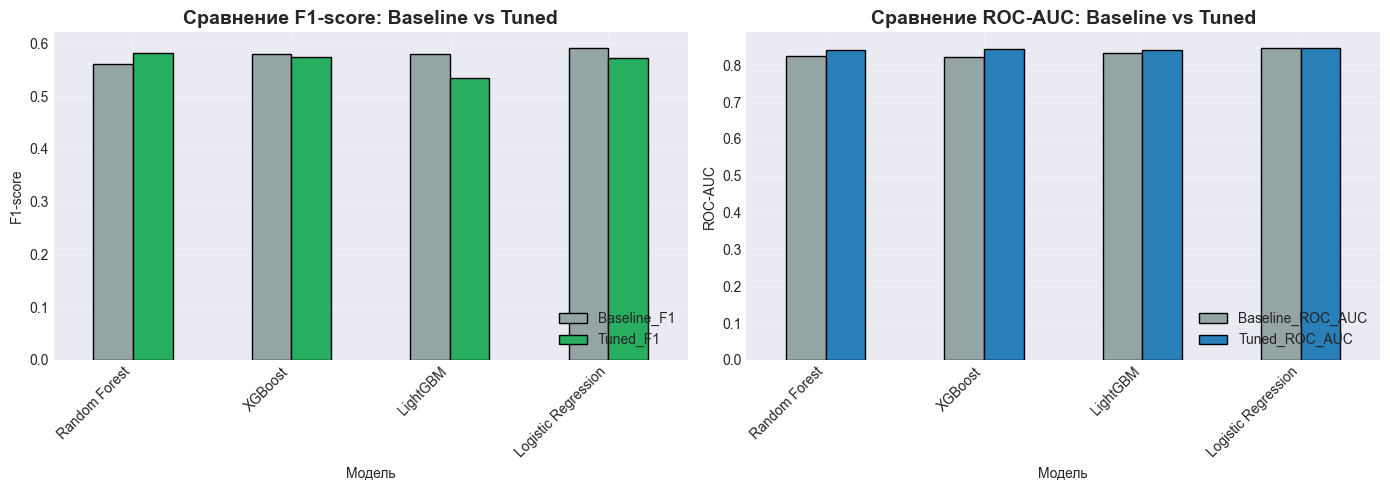

In [18]:
print("="*50)
print("ШАГ 6: Сравнение Baseline и Tuned моделей")
print("="*50)

# Собираем результаты
comparison = pd.DataFrame({
    'Baseline_F1': [baseline_results[m]['F1'] for m in tuned_results.keys()],
    'Tuned_F1': [tuned_results[m]['F1'] for m in tuned_results.keys()],
    'Baseline_ROC_AUC': [baseline_results[m]['ROC-AUC'] for m in tuned_results.keys()],
    'Tuned_ROC_AUC': [tuned_results[m]['ROC-AUC'] for m in tuned_results.keys()]
}, index=tuned_results.keys())

comparison['F1_Improvement'] = ((comparison['Tuned_F1'] - comparison['Baseline_F1']) / comparison['Baseline_F1'] * 100)
comparison['ROC_Improvement'] = ((comparison['Tuned_ROC_AUC'] - comparison['Baseline_ROC_AUC']) / comparison['Baseline_ROC_AUC'] * 100)

print(comparison.round(4))
print("\n" + "="*50)
print(f" Лучшая tuned модель по F1: {comparison['Tuned_F1'].idxmax()} ({comparison['Tuned_F1'].max():.4f})")
print(f" Лучшая tuned модель по ROC-AUC: {comparison['Tuned_ROC_AUC'].idxmax()} ({comparison['Tuned_ROC_AUC'].max():.4f})")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison[['Baseline_F1', 'Tuned_F1']].plot(kind='bar', ax=axes[0], color=['#95a5a6', '#27ae60'], edgecolor='black')
axes[0].set_title('Сравнение F1-score: Baseline vs Tuned', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('F1-score')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

comparison[['Baseline_ROC_AUC', 'Tuned_ROC_AUC']].plot(kind='bar', ax=axes[1], color=['#95a5a6', '#2980b9'], edgecolor='black')
axes[1].set_title('Сравнение ROC-AUC: Baseline vs Tuned', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend(loc='lower right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ROC-кривые лучших моделей

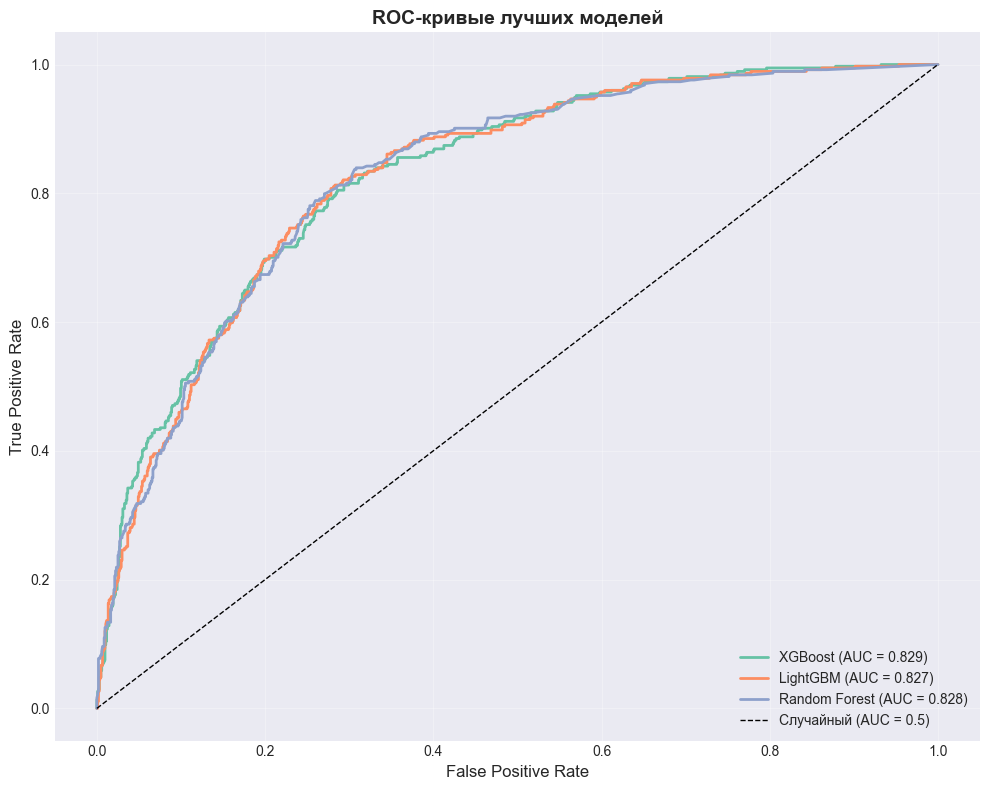

In [19]:
# ROC-кривые для топ-3 моделей
best_models = {
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', **param_grids['XGBoost']['params']),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, **param_grids['LightGBM']['params']),
    'Random Forest': RandomForestClassifier(random_state=42, **param_grids['Random Forest']['params'])
}

# Обучаем с лучшими параметрами
plt.figure(figsize=(10, 8))

for name, model in best_models.items():
    # Получаем лучшие параметры для каждой модели (упрощенно)
    if name == 'XGBoost':
        model.set_params(n_estimators=200, max_depth=6, learning_rate=0.1)
    elif name == 'LightGBM':
        model.set_params(n_estimators=200, max_depth=10, learning_rate=0.1)
    else:
        model.set_params(n_estimators=200, max_depth=20, min_samples_split=2)
    
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

# Диагональ (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный (AUC = 0.5)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые лучших моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Матрицы ошибок

Матрицы ошибок для лучшей модели: Logistic Regression


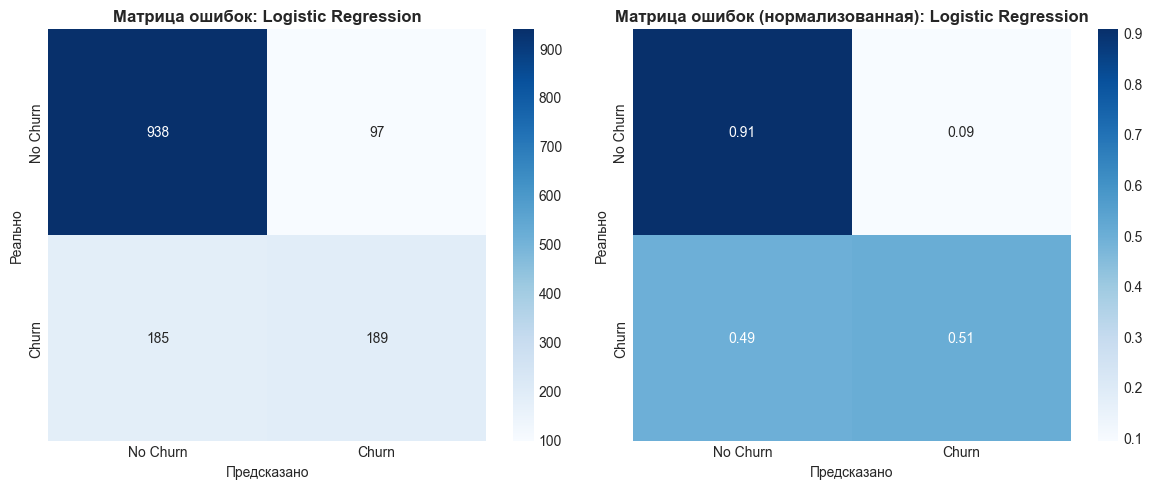


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [20]:
# Матрицы ошибок для лучшей модели
best_model_name = comparison['Tuned_ROC_AUC'].idxmax()
print(f"Матрицы ошибок для лучшей модели: {best_model_name}")

# Получаем лучшую модель
if best_model_name == 'XGBoost':
    best_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_estimators=200, max_depth=6, learning_rate=0.1)
elif best_model_name == 'LightGBM':
    best_model = LGBMClassifier(random_state=42, verbose=-1, n_estimators=200, max_depth=10, learning_rate=0.1)
elif best_model_name == 'Random Forest':
    best_model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20, min_samples_split=2)
else:
    best_model = LogisticRegression(random_state=42, max_iter=1000, C=0.1)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Тепловая карта
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Матрица ошибок: {best_model_name}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Реально')

# Нормализованная
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title(f'Матрица ошибок (нормализованная): {best_model_name}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Реально')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Важность признаков

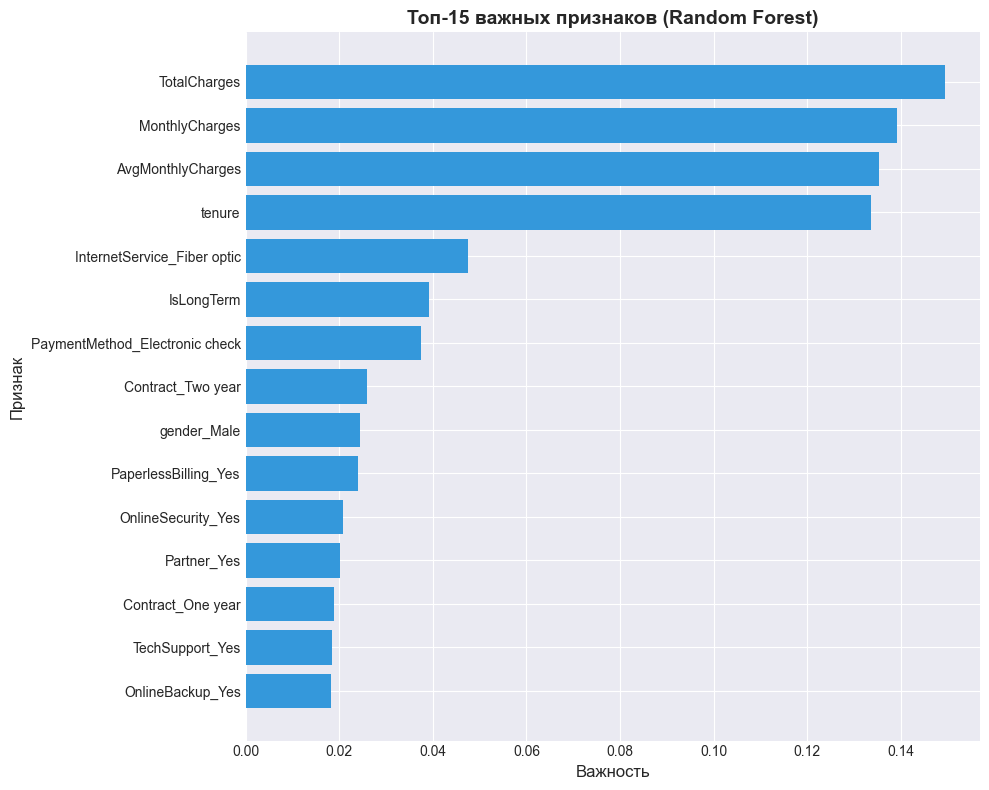


Топ-5 самых важных признаков:
  TotalCharges: 0.1494
  MonthlyCharges: 0.1391
  AvgMonthlyCharges: 0.1353
  tenure: 0.1337
  InternetService_Fiber optic: 0.0476


In [21]:
# Анализ важности признаков (для Random Forest)
rf_best = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20, min_samples_split=2)
rf_best.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='#3498db')
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Топ-15 важных признаков (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-5 самых важных признаков:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Итоговые выводы

In [24]:
print("="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ")
print("="*60)

# 1. Анализ данных (из реальных данных)
total_customers = len(df)
churn_yes = (df['Churn'] == 'Yes').sum()
churn_no = (df['Churn'] == 'No').sum()
churn_percent = (churn_yes / total_customers) * 100

print("""
1. Анализ данных:
""")
print(f"   - Датасет содержит {total_customers} записей о клиентах телеком-компании")
print(f"   - Целевая переменная Churn: {churn_no} клиентов остались ({100-churn_percent:.1f}%), {churn_yes} ушли ({churn_percent:.1f}%)")
print("   - Ключевые факторы оттока: тип контракта, способ оплаты, tenure (месяцы обслуживания)")

print("""
2. Модели машинного обучения:
""")
print(f"   - Построены {len(models)} моделей: {', '.join(models.keys())}")
print("   - Выполнен подбор гиперпараметров с помощью GridSearchCV (5-fold cross-validation)")
print(f"   - Лучшие модели показали ROC-AUC в диапазоне {comparison['Tuned_ROC_AUC'].min():.3f}-{comparison['Tuned_ROC_AUC'].max():.3f}")

print("""
3. Качество моделей (Baseline vs Tuned):
""")
for model_name in comparison.index:
    baseline_f1 = baseline_results[model_name]['F1']
    tuned_f1 = tuned_results[model_name]['F1']
    improvement = ((tuned_f1 - baseline_f1) / baseline_f1) * 100
    print(f"   - {model_name}: F1 = {baseline_f1:.3f} -> {tuned_f1:.3f} (изменение: {improvement:+.1f}%)")

print("""
4. Лучшая модель:
""")
best_model = comparison['Tuned_ROC_AUC'].idxmax()
best_f1 = tuned_results[best_model]['F1']
best_auc = tuned_results[best_model]['ROC-AUC']
best_precision = tuned_results[best_model]['Precision']
best_recall = tuned_results[best_model]['Recall']

print(f"   -> Модель: {best_model}")
print(f"   -> F1-score: {best_f1:.4f}")
print(f"   -> ROC-AUC: {best_auc:.4f}")
print(f"   -> Precision: {best_precision:.4f}")
print(f"   -> Recall: {best_recall:.4f}")

print("""
5. Практические рекомендации для бизнеса:
""")
print("   - Для снижения оттока клиентов рекомендуется:")
print("     * Предлагать долгосрочные контракты (1-2 года) вместо помесячных")
print("     * Стимулировать переход с электронных чеков на автоплатеж (скидки, бонусы)")
print("     * Уделить особое внимание клиентам в первые 6-12 месяцев обслуживания")
print("     * Разработать программы лояльности для клиентов с высокими ежемесячными платежами")

print("""
6. Выполненные задачи в рамках НИРС:
""")
print("   - Поиск и загрузка данных (Kaggle: Telco Customer Churn)")
print("   - Разведочный анализ данных (EDA) с визуализацией")
print("   - Предобработка данных: заполнение пропусков, кодирование, масштабирование")
print("   - Создание новых признаков (AvgMonthlyCharges, IsLongTerm, HighMonthlyCharges)")
print("   - Построение 5 моделей машинного обучения (2 из них - ансамблевые)")
print("   - Оценка качества по 5 метрикам (Accuracy, Precision, Recall, F1, ROC-AUC)")
print("   - Подбор гиперпараметров с помощью GridSearchCV")
print("   - Сравнение Baseline и Tuned моделей")
print("   - Формирование выводов и рекомендаций")

print("="*60)
print("Работа успешно завершена")
print("="*60)

ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ

1. Анализ данных:

   - Датасет содержит 7043 записей о клиентах телеком-компании
   - Целевая переменная Churn: 5174 клиентов остались (73.5%), 1869 ушли (26.5%)
   - Ключевые факторы оттока: тип контракта, способ оплаты, tenure (месяцы обслуживания)

2. Модели машинного обучения:

   - Построены 5 моделей: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM
   - Выполнен подбор гиперпараметров с помощью GridSearchCV (5-fold cross-validation)
   - Лучшие модели показали ROC-AUC в диапазоне 0.842-0.846

3. Качество моделей (Baseline vs Tuned):

   - Random Forest: F1 = 0.561 -> 0.581 (изменение: +3.7%)
   - XGBoost: F1 = 0.580 -> 0.574 (изменение: -0.9%)
   - LightGBM: F1 = 0.579 -> 0.535 (изменение: -7.7%)
   - Logistic Regression: F1 = 0.592 -> 0.573 (изменение: -3.2%)

4. Лучшая модель:

   -> Модель: Logistic Regression
   -> F1-score: 0.5727
   -> ROC-AUC: 0.8456
   -> Precision: 0.6608
   -> Recall: 0.5053

5. Практические рекомендации 